In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# import scipy.io
from poisson_glm_granger import compute_granger_causality, compute_optimal_lags
# from joblib import Parallel, delayed
from statsmodels.stats.multitest import multipletests
import pickle

In [2]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [8]:
plt.rcParams.update({
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
conditions=['GO','SS','FS']

In [5]:
c3_pc=2
f4_pc=10

In [15]:
n_q=3
unit_labels=[]
region_labels=['C3','F4']
region_pcs={
    'C3': [c3_pc],
    'F4': [f4_pc]
}
for region in region_labels:
    for pc in region_pcs[region]:
        for q in range(n_q):
            unit_labels.append(f'{region}-PC{pc+1}-T{q+1}')
n_units=len(unit_labels)

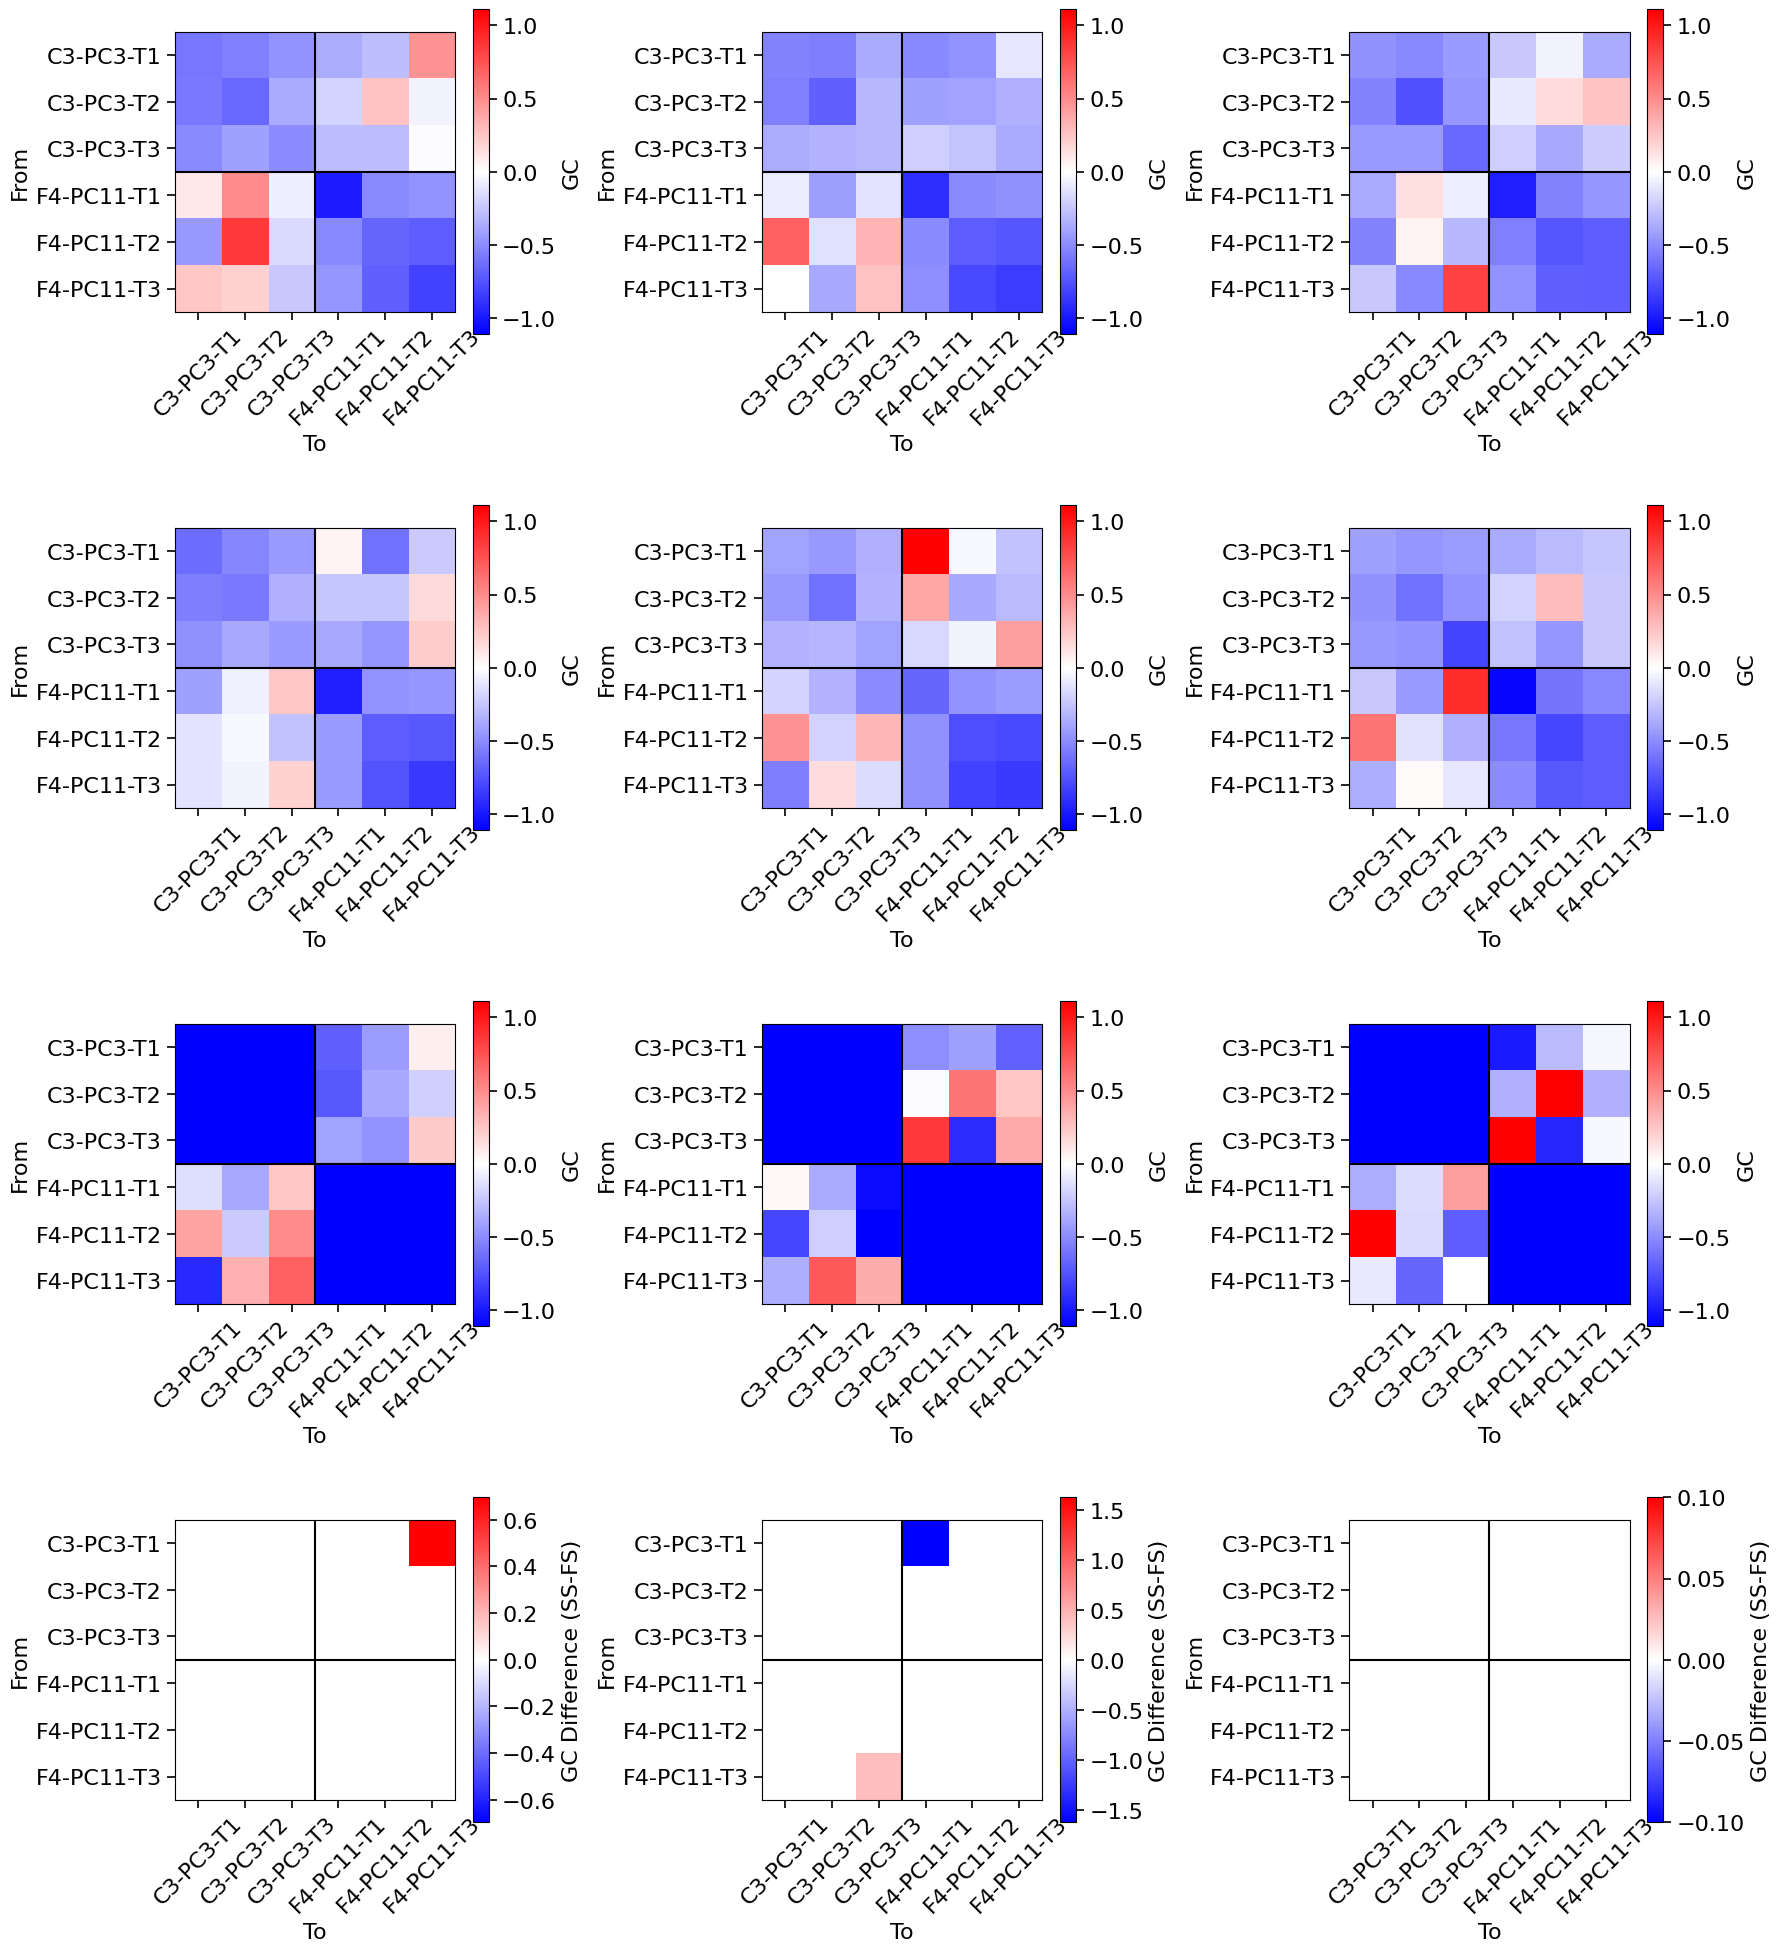

In [16]:
fig = plt.figure(figsize=(18, 20))
gs = GridSpec(4, 3)

fname=f'./output/connectivity_t1_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
data=np.load(fname, allow_pickle=True)
pc_unit_labels=data['unit_labels'][()]
t1_signed_gc_matrices=data['signed_gc_matrices'][()]
t1_diff_gc_matrices=data['diff_gc_matrices'][()]
t1_p_values_diff=data['p_values_diff'][()]

fname=f'./output/connectivity_t2_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
data=np.load(fname, allow_pickle=True)
t2_signed_gc_matrices=data['signed_gc_matrices'][()]
t2_diff_gc_matrices=data['diff_gc_matrices'][()]
t2_p_values_diff=data['p_values_diff'][()]

fname=f'./output/connectivity_t3_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
data=np.load(fname, allow_pickle=True)
t3_signed_gc_matrices=data['signed_gc_matrices'][()]
t3_diff_gc_matrices=data['diff_gc_matrices'][()]
t3_p_values_diff=data['p_values_diff'][()]

# Calculate a dynamic clim based on all conditions
all_gc_values = []
for cond in ['FS','SS']:
    t1_significant_gc_matrix = np.mean(np.array(t1_signed_gc_matrices[cond]), axis=0)
    t2_significant_gc_matrix = np.mean(np.array(t2_signed_gc_matrices[cond]), axis=0)
    t3_significant_gc_matrix = np.mean(np.array(t3_signed_gc_matrices[cond]), axis=0)
    # significant_gc_matrix[one_samp_p_values[cond] >= 0.05] = 0
    all_gc_values.extend(t1_significant_gc_matrix.flatten())
    all_gc_values.extend(t2_significant_gc_matrix.flatten())
    all_gc_values.extend(t3_significant_gc_matrix.flatten())
common_clim = [-max(abs(np.min(all_gc_values)), np.max(all_gc_values)), max(abs(np.min(all_gc_values)), np.max(all_gc_values))]

ax = fig.add_subplot(gs[0, 0])
significant_gc_matrix = np.mean(np.array(t1_signed_gc_matrices['SS']), axis=0)
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[0, 1])
significant_gc_matrix = np.mean(np.array(t2_signed_gc_matrices['SS']), axis=0)
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[0, 2])
significant_gc_matrix = np.mean(np.array(t3_signed_gc_matrices['SS']), axis=0)
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')



ax = fig.add_subplot(gs[1, 0])
significant_gc_matrix = np.mean(np.array(t1_signed_gc_matrices['FS']), axis=0)
# significant_gc_matrix[one_samp_p_values['FS'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[1, 1])
significant_gc_matrix = np.mean(np.array(t2_signed_gc_matrices['FS']), axis=0)
# significant_gc_matrix[one_samp_p_values['FS'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[1, 2])
significant_gc_matrix = np.mean(np.array(t3_signed_gc_matrices['FS']), axis=0)
# significant_gc_matrix[one_samp_p_values['FS'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')


ax = fig.add_subplot(gs[2, 0])
significant_gc_matrix = np.mean(np.array(t1_signed_gc_matrices['GO']), axis=0)
# significant_gc_matrix[one_samp_p_values['GO'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[2, 1])
significant_gc_matrix = np.mean(np.array(t2_signed_gc_matrices['GO']), axis=0)
# significant_gc_matrix[one_samp_p_values['GO'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')

ax = fig.add_subplot(gs[2, 2])
significant_gc_matrix = np.mean(np.array(t3_signed_gc_matrices['GO']), axis=0)
# significant_gc_matrix[one_samp_p_values['GO'] >= 0.05] = 0
# Visualize results
im = ax.imshow(significant_gc_matrix, cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC')


    
# Plot the GC difference
ax = fig.add_subplot(gs[3, 0])
significant_diff_gc_matrix = np.mean(t1_diff_gc_matrices, axis=0)
significant_diff_gc_matrix[t1_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC Difference (SS-FS)')

ax = fig.add_subplot(gs[3, 1])
significant_diff_gc_matrix = np.mean(t2_diff_gc_matrices, axis=0)
significant_diff_gc_matrix[t2_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC Difference (SS-FS)')

ax = fig.add_subplot(gs[3, 2])
significant_diff_gc_matrix = np.mean(t3_diff_gc_matrices, axis=0)
significant_diff_gc_matrix[t3_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color='k')
plt.axhline(2.5,color='k')
plt.colorbar(im, label='GC Difference (SS-FS)')


plt.tight_layout()

plt.savefig('./figures/figure_xx_connectivity.pdf')